# Проект анализа данных Яндекс Афиши

Выполнила: Элеонора Говоровская

## Цель и задачи проекта
**Цель проекта:**

Проследить изменения пользовательских предпочтений и популярности событий осенью 2024 года при оформлении заказов на билеты на мероприятия, а также проверить гипотезу о разнице в поведении пользователей с мобильных и стационарных устройств.

**Задачи проекта:**

1. Проанализировать распределение заказов в зависимости от категории устройства, типа мероприятия и возрастного рейтинга и выявить сезонные изменения, сравнив летние и осенние показатели. 
2. Изучить изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью, чтобы отследить динамику в разрезе разных категорий мероприятий.
3. Проанализировать осенню динамику изменений по дням для общего числа заказов,количества активных пользователей DAU, среднего числа заказов на одного пользователя и средней стоимости одного билета.
4. Изучить распределение уникальных событий по регионам и партнёрам сервиса.
5. С помощью статистических тестов проверить гипотезы о том, что среднее количество заказов и среднее количество времени между заказами выше у пользователей мобильных приложений в сравнению с пользователями стационарных устройств.

## Описание данных

Первый датасет final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных.

- `order_id` — уникальный идентификатор заказа.

- `user_id` — уникальный идентификатор пользователя.

- `created_dt_msk` — дата создания заказа (московское время).

- `created_ts_msk` — дата и время создания заказа (московское время).

- `event_id` — идентификатор мероприятия из таблицы events.

- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.

- `age_limit` — возрастное ограничение мероприятия.

- `currency_code` — валюта оплаты, например rub для российских рублей.

- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.

- `revenue` — выручка от заказа.

- `service_name` — название билетного оператора.

- `tickets_count` — количество купленных билетов.

- `total` — общая сумма заказа.

Второй датасет final_tickets_events_df.csv содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:

- `event_id` — уникальный идентификатор мероприятия.

- `event_name` — название мероприятия. 

- `event_type_description` — описание типа мероприятия.

- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.

- `organizers` — организаторы мероприятия.

- `region_name` — название региона.

- `city_name` — название города.

- `venue_id` — уникальный идентификатор площадки.

- `venue_name` — название площадки.

- `venue_address` — адрес площадки.

датасет final_tickets_tenge_df.csv содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:

- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt).

## Структура проекта

1. Знакомство с данными и загрузка
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
4. Статистический анализ данных

## Шаг 1. Загрузка данных и знакомство с ними

In [1]:
# загружаем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import string
from scipy import stats
from scipy.stats import mannwhitneyu

In [2]:
# загружаем первый датасет orders и выводим первые пять строчек
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [3]:
# проверяем основную информацию о датасете
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
# загружаем датасет events и выгружаем первые пять строчек
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [5]:
# проверяем информацию о датасете и типах данных
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [6]:
# загружаем информацию о курсе тенге за 2024 год
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [7]:
# проверяем информацию о датасете
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


### Вывод о загрузке данных и знакомстве с ними

Для работы было создано и загружено три датасета:
- Датасет `orders` содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Он включает в себя 14 столбцов и 290849 строчек. Пропуски содержатся только в столбце `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя.
- Датасет `events` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. В нем 22427 строчки и 11 столбцов. Не содержит пропусков.
-  Датасет `tenge` включает информацию о курсе тенге за 2024 год. Он содержит 357 строчек и 4 столбца.

Почти все данные приведены к правильным форматам и не содержат пропусков за исключением столбца `days_since_prev`. Стоит привести `creaed_dt_msk` и `data` к временному формату.

## Шаг 2. Предобработка данных и подготовка их к исследованию

Проверим успешную выгрузку данных: ожидаем пропуски только в столбце `days_since_prev`.

In [8]:
# объединяем датасеты orders и events для удобства работы 

afisha = orders.merge(events, how='inner', on='event_id')

afisha.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [9]:
# проверяем пропуски в датасете: они могут быть только в столбце `days_since_prev`
afisha.isna().sum()


order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

Изучим значения в ключевых столбцах: проверим категориальные значения, а также выбросы.

In [10]:
# проверяем значения в ключевых категориальных столбцах
devices = afisha['device_type_canonical'].unique()
currencies = afisha['currency_code'].unique()
event_types = afisha['event_type_main'].unique()
event_description = afisha['event_type_description'].unique()
cinema_circuit = afisha['cinema_circuit'].unique()
service_name = afisha['service_name'].unique()

print(devices, currencies, event_types, event_description, cinema_circuit, service_name)

['mobile' 'desktop'] ['rub' 'kzt'] ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки'] ['спектакль' 'событие' 'цирковое шоу' 'выставка' 'шоу' 'концерт' 'спорт'
 'мюзикл' 'фестиваль' 'ёлка' 'балет' 'спортивное мероприятие' 'опера'
 'музыкальный спектакль' 'кукольный спектакль' 'оперетта' 'снегурочка'
 'рок-мюзикл' 'экскурсия' 'подарок'] ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм'] ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']


Уникальные категориальные значения были проверены, в них не обнаружено скрытых дубликатов. Далее проанализируем выбросы в столбцах с числовыми значениями.

In [11]:
# перед анализом выбросов разделяем тенге и рубли

afisha_rub = afisha[afisha['currency_code'] == 'rub'].copy()
afisha_kzt = afisha[afisha['currency_code'] == 'kzt'].copy()

# проверяем распределения и наличие выбросов в ключевых столбцах revenue и tickets_count в рублевой валюте

afisha_rub[['revenue', 'tickets_count']].describe()



,revenue,tickets_count
count,285542.000000,285542.000000
mean,548.013929,2.754159
std,871.750181,1.171575
min,-90.760000,1.000000
25%,114.170000,2.000000
50%,346.630000,3.000000
75%,793.320000,4.000000
max,81174.540000,57.000000


In [12]:
# то же самое рассматриваем и в случае тенге
afisha_kzt[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
max,26425.860000,6.000000


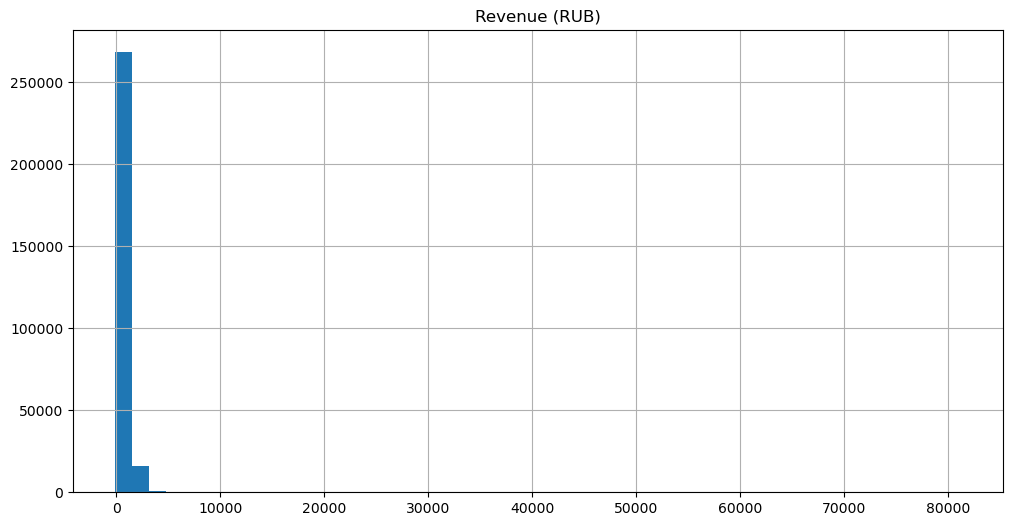

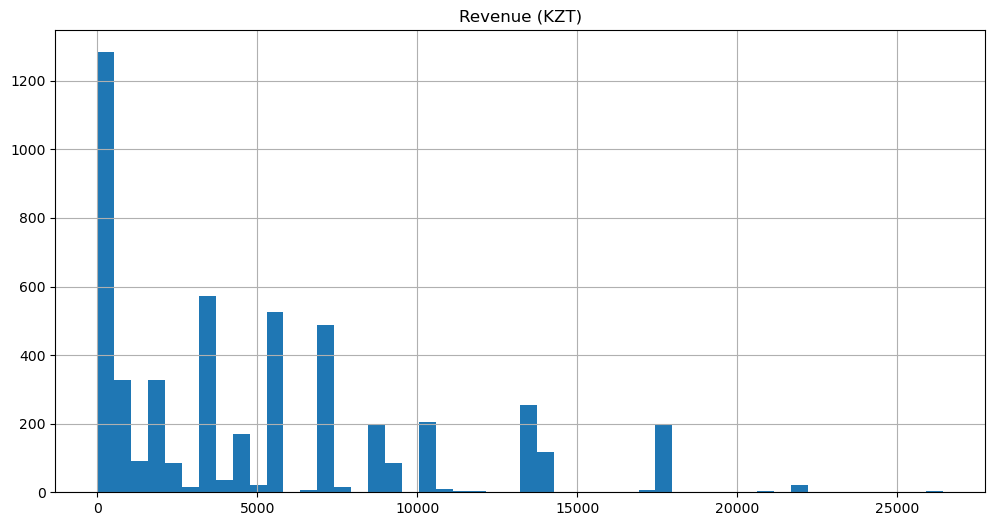

In [13]:
# строим гистограммы revenue

afisha_rub['revenue'].hist(bins=50, figsize=(12, 6))
plt.title('Revenue (RUB)')
plt.show()

afisha_kzt['revenue'].hist(bins=50, figsize=(12, 6))
plt.title('Revenue (KZT)')
plt.show()

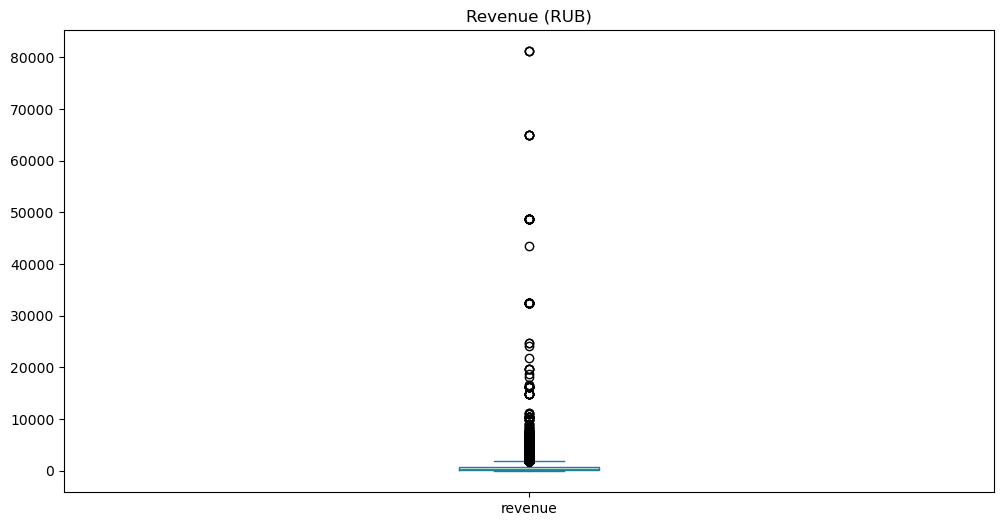

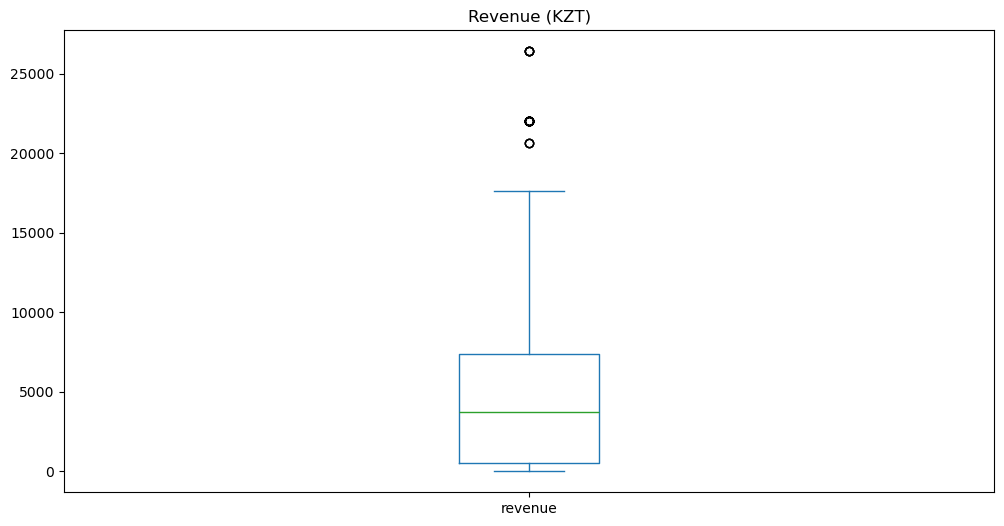

In [14]:
# строим ящики с усами

afisha_rub['revenue'].plot.box(figsize=(12, 6))
plt.title('Revenue (RUB)')
plt.show()

afisha_kzt['revenue'].plot.box(figsize=(12, 6))
plt.title('Revenue (KZT)')
plt.show()

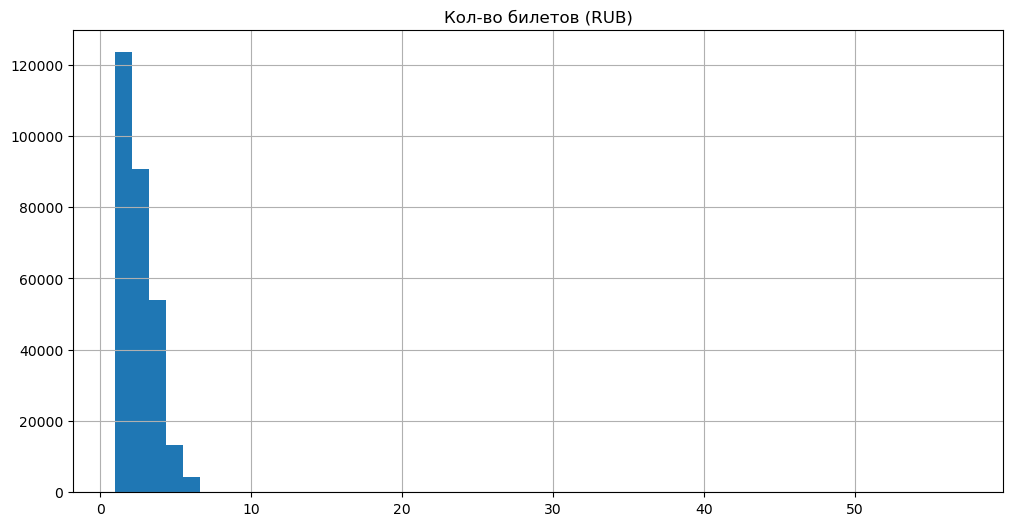

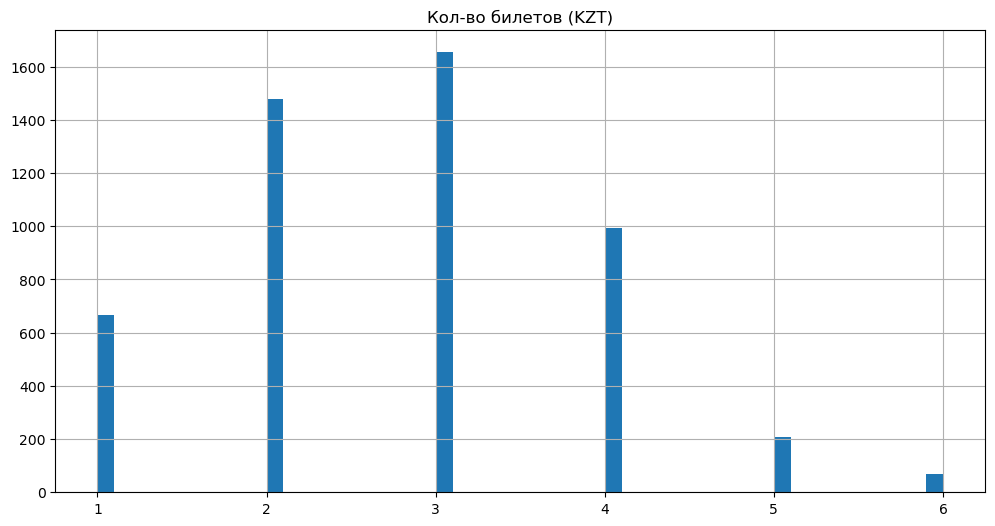

In [15]:
# строим гистограммы tickets count

afisha_rub['tickets_count'].hist(bins=50, figsize=(12, 6))
plt.title('Кол-во билетов (RUB)')
plt.show()

afisha_kzt['tickets_count'].hist(bins=50, figsize=(12, 6))
plt.title('Кол-во билетов (KZT)')
plt.show()

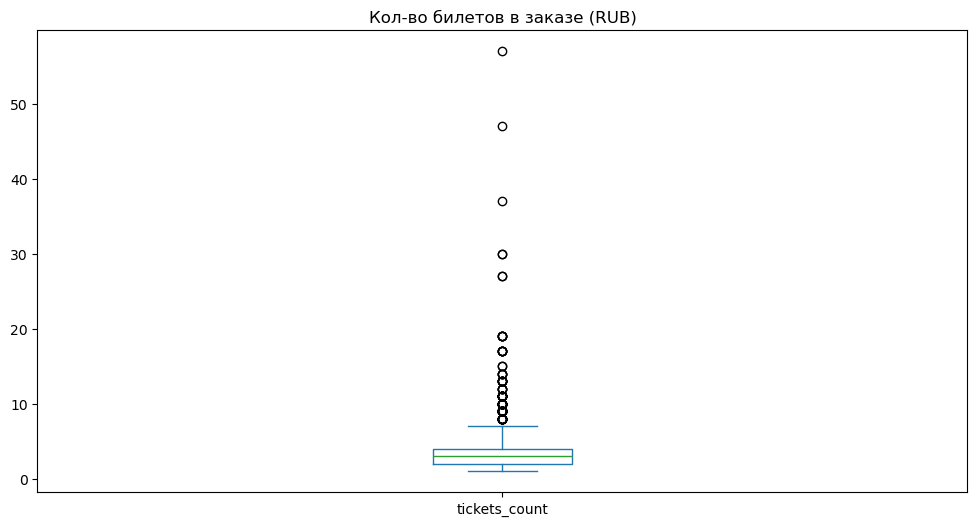

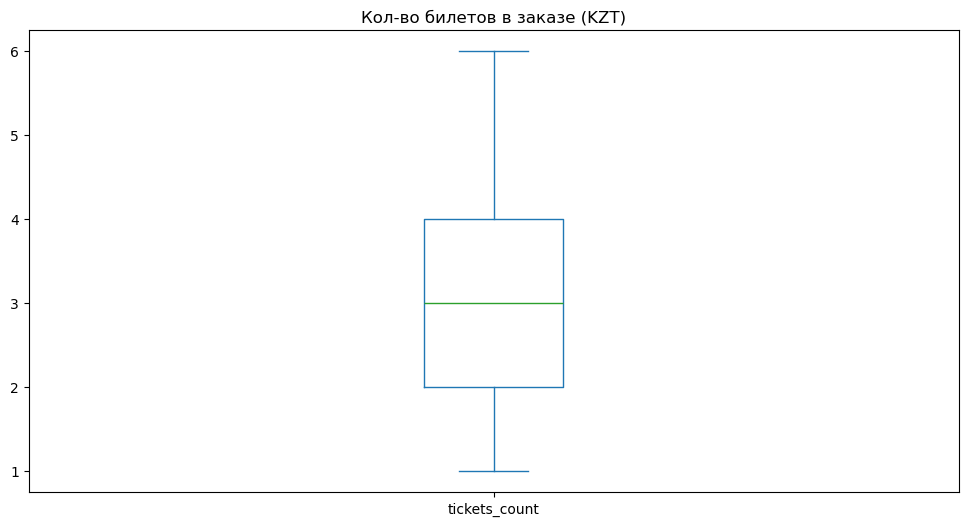

In [16]:
afisha_rub['tickets_count'].plot.box(figsize=(12, 6))
plt.title('Кол-во билетов в заказе (RUB)')
plt.show()

afisha_kzt['tickets_count'].plot.box(figsize=(12, 6))
plt.title('Кол-во билетов в заказе (KZT)')
plt.show()



- В данных есть выбросы по столбцу revenue, такие как отрицательные значения или экстремально высокие значения. Обработаем их, используя 99-перцентиль, а также исключим отрицательные значения.
- В данных по столбцу tickets_count также есть аномальные значения при покупке рублях -- единичные покупки на 40-50 билетов. Их также можно исключить.

In [17]:
# вычисляем 99 квантиль
p99_rub = afisha_rub['revenue'].quantile(0.99)
p99_kzt = afisha_kzt['revenue'].quantile(0.99)
p99_tickets_rub = afisha_rub['tickets_count'].quantile(0.99)

# фильтруем датасеты и оставляем те значения, которые попадают в 99й перцентиль, а также исключаем отрицательные значения выручки
afisha_rub_filtered = afisha_rub[(afisha_rub['revenue'] <= p99_rub) & (afisha_rub['revenue'] >= 0) & (afisha_rub['tickets_count'] <= p99_tickets_rub)]
afisha_kzt_filtered = afisha_kzt[(afisha_kzt['revenue'] <= p99_kzt) & (afisha_kzt['revenue'] >= 0)]

# проверяем датасет с рублями
afisha_rub_filtered['revenue'].describe()

count    282181.000000
mean        511.254352
std         500.811082
min           0.000000
25%         112.950000
50%         341.350000
75%         782.030000
max        2570.800000
Name: revenue, dtype: float64

In [18]:
# проверяем tickets_count в afisha_rub_filtered
afisha_rub_filtered['tickets_count'].describe()

count    282181.000000
mean          2.735964
std           1.136158
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: tickets_count, dtype: float64

In [19]:
# проверяем датасет с тенге
afisha_kzt_filtered['revenue'].describe()

count     5040.000000
mean      4893.669063
std       4742.680176
min          0.000000
25%        515.350000
50%       3698.830000
75%       7397.660000
max      17617.240000
Name: revenue, dtype: float64

In [20]:
# объединяем отфильтрованные датафреймы снова в один

new_afisha = pd.concat([afisha_rub_filtered, afisha_kzt_filtered])

new_afisha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287221 entries, 0 to 290489
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287221 non-null  int64  
 1   user_id                 287221 non-null  object 
 2   created_dt_msk          287221 non-null  object 
 3   created_ts_msk          287221 non-null  object 
 4   event_id                287221 non-null  int64  
 5   cinema_circuit          287221 non-null  object 
 6   age_limit               287221 non-null  int64  
 7   currency_code           287221 non-null  object 
 8   device_type_canonical   287221 non-null  object 
 9   revenue                 287221 non-null  float64
 10  service_name            287221 non-null  object 
 11  tickets_count           287221 non-null  int64  
 12  total                   287221 non-null  float64
 13  days_since_prev         265556 non-null  float64
 14  event_name              2

Проверим явные и неявные дубликаты.

In [21]:
# приводим к нижнему регистру
string_cols = new_afisha.select_dtypes(include=['object']).columns
new_afisha[string_cols] = new_afisha[string_cols].apply(lambda x: x.str.lower())

# очищаем от знаков препинания
cols_to_fix = ['service_name', 'organizers', 'venue_name', 'venue_address']
for col in cols_to_fix:
    if col in new_afisha.columns:
        new_afisha[col] = new_afisha[col].str.replace(r'[^\w\s]', '', regex=True)

# удаляем полные дубликаты
new_afisha = new_afisha.drop_duplicates()

In [22]:
# теперь работаем с неявными дубликатами. создаем новый датасет, откуда убираем ненужные для анализа индентификатор заказов, валюту, выручку и общую сумму total
# так отследим, какие заказы попали 
duplicates = new_afisha.copy()
duplicates.drop(['order_id', 'currency_code', 'revenue','total'], axis=1,  inplace=True)
print(len(duplicates))
display(duplicates.head())

287221


,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,device_type_canonical,service_name,tickets_count,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,mobile,край билетов,4,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,3322,каменевский регион,глиногорск,213,3972,сценический центр деталь групп,алл машиностроителей д 19 стр 6
1,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,mobile,мой билет,2,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,4850,каменевский регион,глиногорск,213,2941,музыкальная школа для детей аккаунт лтд,алл шмидта д 9 стр 4
2,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,mobile,за билетом,4,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,1540,каменевский регион,глиногорск,213,4507,училище искусств нирвана инк,алл юбилейная д 56
3,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,mobile,лови билет,2,NaN,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,5049,североярская область,озёрск,2,3574,театр альтернативного искусства ода лимитед,алл есенина д 243 к 38
4,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,mobile,билеты без проблем,3,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,832,озернинский край,родниковецк,240,1896,театр кукол огни инкорпорэйтед,ш набережное д 595 стр 8


In [23]:
# проверяем полные дубликаты по получившемуся субдатасету: это и есть неявные дубликаты new_afisha
new_afisha_duplicates = duplicates.duplicated().sum()
print(new_afisha_duplicates)

30


In [24]:
# получаем индексы строк, которые НЕ являются дубликатами
non_duplicate_indices = ~duplicates.duplicated(keep='first')

# фильтруем new_afisha
new_afisha = new_afisha[non_duplicate_indices.values]

print(f"Очищенный датасет: {len(new_afisha)} строк")

Очищенный датасет: 287191 строк


Проведем преобразование типов данных: изменим размерность, а также приведем столбцы к формату даты и времени.

In [25]:
# изменяем размерность количественных данных в датафрейме
for column in ['order_id', 'event_id', 'age_limit', 'tickets_count', 'city_id', 'venue_id']:
    new_afisha[column] =pd.to_numeric(new_afisha[column], downcast='integer')

new_afisha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287191 entries, 0 to 290489
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287191 non-null  int32  
 1   user_id                 287191 non-null  object 
 2   created_dt_msk          287191 non-null  object 
 3   created_ts_msk          287191 non-null  object 
 4   event_id                287191 non-null  int32  
 5   cinema_circuit          287191 non-null  object 
 6   age_limit               287191 non-null  int8   
 7   currency_code           287191 non-null  object 
 8   device_type_canonical   287191 non-null  object 
 9   revenue                 287191 non-null  float64
 10  service_name            287191 non-null  object 
 11  tickets_count           287191 non-null  int8   
 12  total                   287191 non-null  float64
 13  days_since_prev         265526 non-null  float64
 14  event_name              2

In [26]:
# приводим столбцы created_dt_msk и data к временному формату
new_afisha['created_dt_msk'] = pd.to_datetime(new_afisha['created_dt_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])
new_afisha['created_ts_msk'] = pd.to_datetime(new_afisha['created_ts_msk'])

Для удобства анализа переведем тенге к рублям.

In [27]:
# присоединяем курс тенге по дате
new_afisha = new_afisha.merge(tenge, left_on='created_dt_msk', right_on='data', how='inner')

In [28]:
# создаем временную колонку с курсом
new_afisha['kzt_rate'] = new_afisha['curs']/new_afisha['nominal']

# создаем копию колонки revenue
new_afisha['revenue_rub'] = new_afisha['revenue'].copy()

# обновляем значения для kz
new_afisha.loc[new_afisha['currency_code'] == 'kzt', 'revenue_rub'] = new_afisha.loc[new_afisha['currency_code'] == 'kzt', 'revenue'] * new_afisha.loc[new_afisha['currency_code'] == 'kzt', 'kzt_rate']

print(new_afisha.loc[new_afisha['currency_code'] == 'kzt', ['currency_code', 'curs', 'nominal', 'kzt_rate', 'revenue', 'revenue_rub']].head(), '\n',
      new_afisha.loc[new_afisha['currency_code'] == 'rub', ['currency_code', 'curs', 'nominal', 'kzt_rate', 'revenue', 'revenue_rub']].head())

# удаляем временную колонку rate
new_afisha = new_afisha.drop('kzt_rate', axis=1)

       currency_code     curs  nominal  kzt_rate  revenue  revenue_rub
282151           kzt  19.0125      100  0.190125   518.10    98.503762
282152           kzt  18.9330      100  0.189330   347.18    65.731589
282153           kzt  18.5991      100  0.185991   328.77    61.148261
282154           kzt  19.9833      100  0.199833  7397.66  1478.296591
282155           kzt  19.9833      100  0.199833  3698.83   739.148295 
   currency_code     curs  nominal  kzt_rate  revenue  revenue_rub
0           rub  18.6972      100  0.186972  1521.94      1521.94
1           rub  18.3419      100  0.183419   289.45       289.45
2           rub  19.6475      100  0.196475  1258.57      1258.57
3           rub  18.5010      100  0.185010     8.49         8.49
4           rub  19.6648      100  0.196648  1390.41      1390.41


создадим столбец `one_ticket_revenue_rub` — выручку с продажи одного билета на мероприятие;

In [29]:
# рассчитываем выручку с продажи одного билета на мероприятие
new_afisha['one_ticket_revenue_rub'] = new_afisha['revenue_rub'] / new_afisha['tickets_count']

- `month` — выделим месяц оформления заказа;

In [30]:
# выделяем месяц оформления заказа
new_afisha['month'] = new_afisha['created_dt_msk'].dt.month_name()

- `season` — создадим столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

In [31]:
# создаем словарь, где присваиваем номеру месяца сезон

season_map = {
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}


# соотносим месяц с сезоном
new_afisha['season'] = new_afisha['created_dt_msk'].dt.month.map(season_map)


In [32]:
# подводим итоги предобработки данных
print(f"Строчек в объединенном датасете events и orders до предобработки: {len(afisha)}.")
print(f"Строчек в датасете после предобработки: {len(new_afisha)}.")
print(f"Сохранено {round(len(new_afisha) / len(afisha), 3) * 100}% данных.")

Строчек в объединенном датасете events и orders до предобработки: 290611.
Строчек в датасете после предобработки: 287191.
Сохранено 98.8% данных.



До предобработки данных в объединенном датасете `events` и `orders` было 290611 строчек.

После объединения датасетов и очистки от единичных выбросов по столбцам `revenue` и `tickets_count` в новом датасете new_afisha осталось 287191 строчек. Было сохранено 98.8% исходных данных.

Были созданы следующие столбцы:
- `revenue_rub` -- выручка приведена к рублям.
- `one_ticket_revenue_rub` -- содержит информацию о выручки с продажи одного билета на мероприятие.
- `month` -- был выделен месяц оформления заказа в отдельный столбец.
- `season` -- создан столбец с названием времен года.

## Шаг 3. Исследовательский анализ данных


Визуализируем количество заказов по месяцам.


In [33]:
# считаем количество заказов в разрезе месяца в абсолютных значениях
order_amount = new_afisha.groupby('month')['order_id'].count().sort_values(ascending=False)
print(order_amount)

month
October      99099
September    69224
August       44497
July         40332
June         34039
Name: order_id, dtype: int64


In [34]:
# считаем кол-во заказов в разрезе месяца в относительных значениях
relative_order_amount = new_afisha['month'].value_counts(normalize=True).round(2)
print(relative_order_amount)

month
October      0.35
September    0.24
August       0.15
July         0.14
June         0.12
Name: proportion, dtype: float64


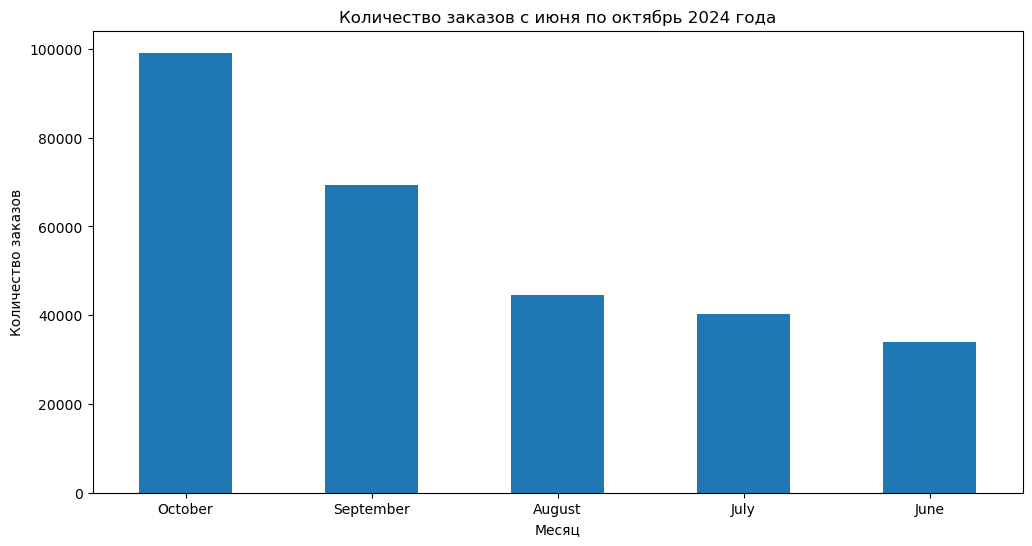

In [35]:
# строим bar chart
new_afisha.groupby('month')['order_id'].count().sort_values(ascending=False).plot(
    kind='bar',
    rot=0,
     figsize=(12, 6))
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.title('Количество заказов с июня по октябрь 2024 года')
plt.show()

Увеличение заказов фиксируется с июня по конец октября. Далее проверим распределение заказов по категориям мероприятия, устройства и возрастного рейтинга.

In [36]:
def plot_distribution(df, category_col):
    # считаем доли
    dist = (
        df  # исправлено: используем параметр df
        .groupby(['season', category_col])
        .size()
        .reset_index(name='count')
    )
    
    # переводим в доли
    dist['share'] = dist.groupby('season')['count'].transform(lambda x: x / x.sum())
    
    # pivot для графика
    pivot = dist.pivot(index='season', columns=category_col, values='share')
    
    # строим stacked bar
    ax = pivot.plot(kind='bar', stacked=True, rot=0, figsize=(12,6))
    
    # Ручное добавление аннотаций
    for i, (season, row) in enumerate(pivot.iterrows()):
        cumsum = 0
        for col in pivot.columns:
            value = row[col]
            if value > 0.02:  # показываем только значимые доли (>2%)
                # вычисляем позицию для текста (центр сегмента)
                y_pos = cumsum + value / 2
                ax.text(i, y_pos, f'{value:.1%}', 
                       ha='center', va='center', fontsize=9)
            cumsum += value
    
    plt.title(f'Распределение по {category_col}')
    plt.ylabel('Доля')
    plt.xlabel('Сезон')
    plt.legend(title=category_col, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

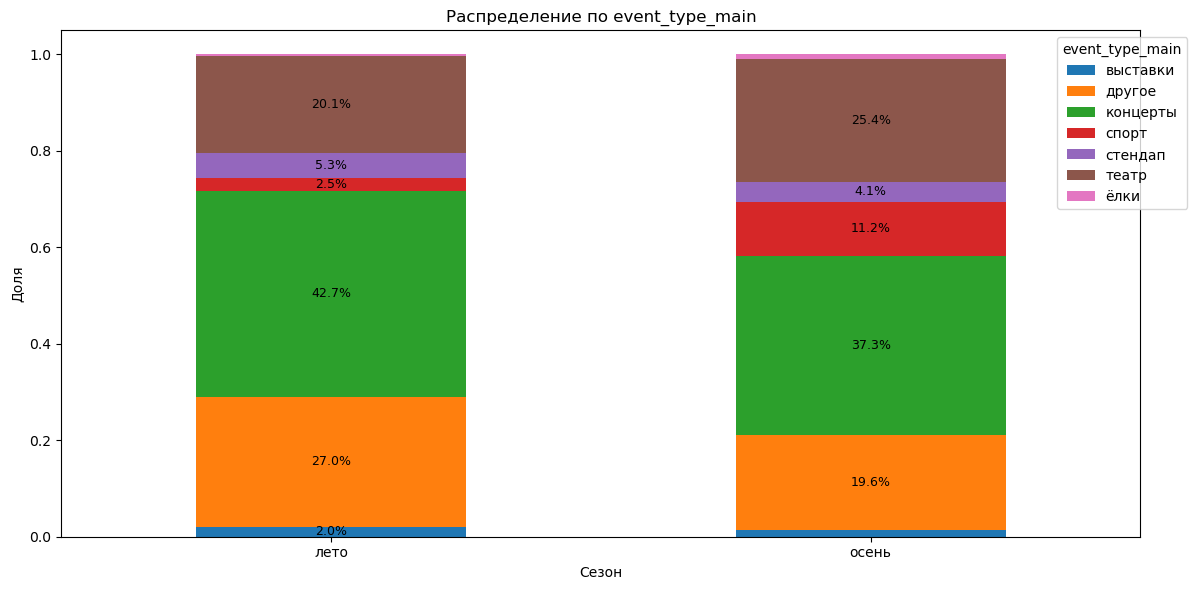

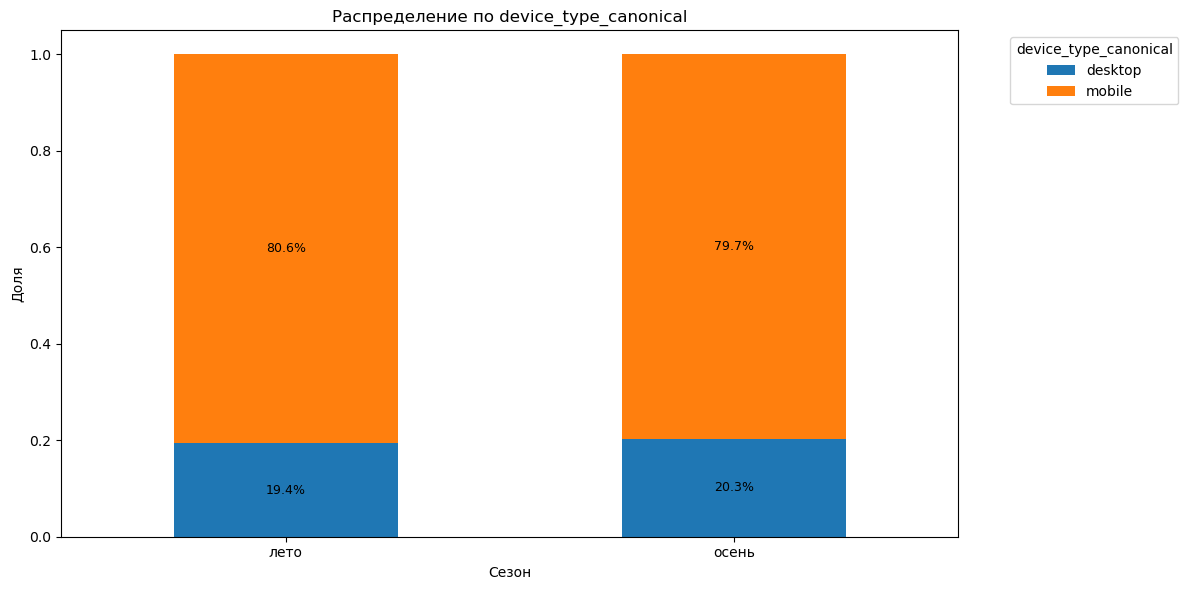

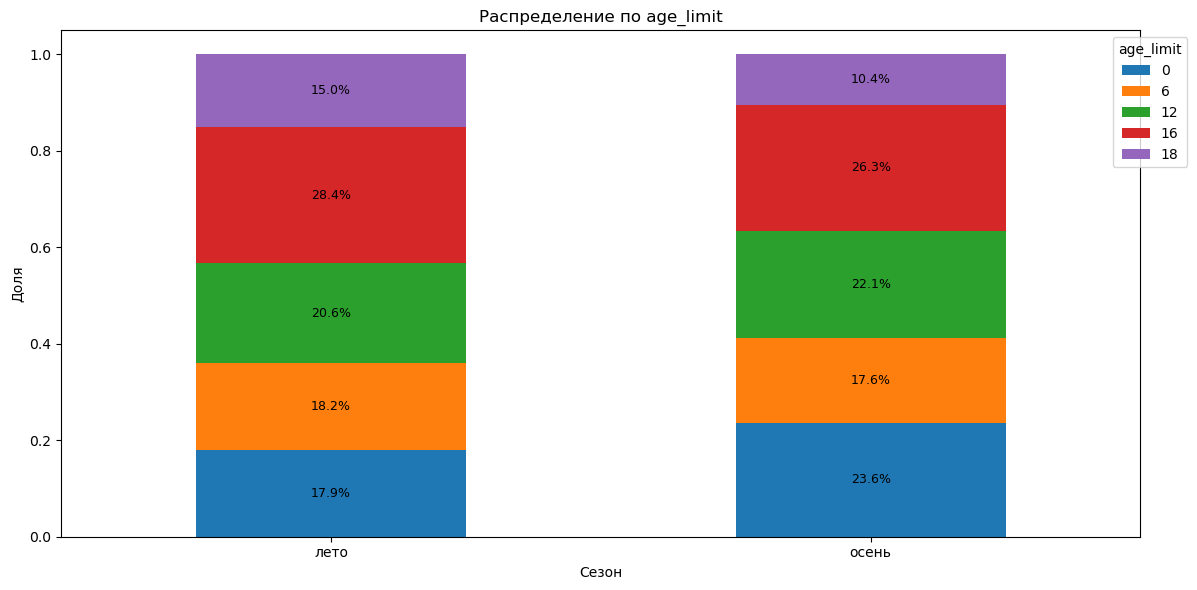

In [37]:
plot_distribution(new_afisha, 'event_type_main')
plot_distribution(new_afisha, 'device_type_canonical')
plot_distribution(new_afisha, 'age_limit')


При сравнении относительных значений количества заказов на разные мероприятия в зависимости от типа события, вида устройства и возрастного рейтинга видны следующие тенденции: 
- Осенью пользователи покупают больше билетов в театр (рост с с 20% до 25%) и на спортивные мероприятия (рост с 2,5% до 11%). Заметен фактор сезонности, так как осенью начинаются продажи на ёлки. 
- Удельный вес всех остальных мероприятий уменьшился: доля концертов уменьшилась с 43% до 37%, доля мероприятий "другое" -- с 27% до 20%. Также продажи билетов на стендапы уменьшились на 1.2 п.п.
- Распределение в зависимости от типа устройства остается практически одинаковым. 
- Осенью доля мероприятий с возрастным рейтингом 0+ больше, чем летом (рост с 18% до 24%), а с возрастным рейтингом 18+ -- меньше (падение с 15% до 10%). Также на 2 п.п. увеличилась доля мероприятий с рейтингом 12+.

Такие изменения могут быть связаны с:
- Концом летнего сезона, во время которого часто проходят концерты и гастроли музыкальных групп;
- Началом обучения в школах, что приводит к повышению спроса на мероприятия для детей школьного возраста;
- Продолжение спортивных туров осенью.

- Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.


In [38]:
# рассчитываем среднее значение выручки с одного билета

avg_rev = new_afisha.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().sort_values(ascending=False).reset_index()

In [39]:
# сравниваем средние значения выручки с одного билета по сезонам
pivot_seasons = avg_rev.pivot(
    index='event_type_main',
    columns='season',
    values='one_ticket_revenue_rub'
)
display(pivot_seasons)

season,лето,осень
event_type_main,,
выставки,86.744476,91.905093
другое,77.784630,76.420455
концерты,304.804906,268.385983
спорт,50.796203,50.038623
стендап,218.518107,231.124973
театр,214.179496,175.984021
ёлки,271.436176,229.564210


In [40]:
# высчитываем относительное изменение осенних значений с летними 
pivot_seasons['change_%'] = (pivot_seasons['осень'] - pivot_seasons['лето']) / pivot_seasons['лето'] * 100
pivot_seasons = pivot_seasons.sort_values('change_%', ascending=False)
display(pivot_seasons)

season,лето,осень,change_%
event_type_main,,,
выставки,86.744476,91.905093,5.949217
стендап,218.518107,231.124973,5.769255
спорт,50.796203,50.038623,-1.491410
другое,77.784630,76.420455,-1.753785
концерты,304.804906,268.385983,-11.948273
ёлки,271.436176,229.564210,-15.426081
театр,214.179496,175.984021,-17.833395


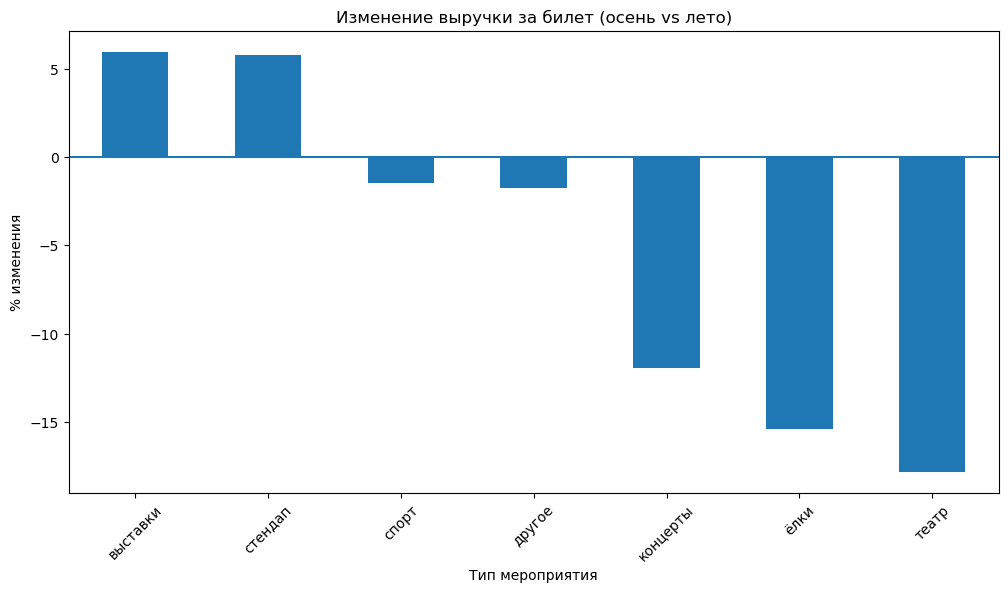

In [41]:
pivot_seasons['change_%'].plot(kind='bar', figsize=(12, 6))

plt.axhline(0)  # линия без изменений
plt.title('Изменение выручки за билет (осень vs лето)')
plt.ylabel('% изменения')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=45)
plt.show()

Выручка с продажи одного билета в осенний период выросла при заказах билетов на выставки и стендапы, но снизилась на все остальные категории мероприяйтий: спорт, концерты, ёлки, театр и "другое".


### Осенняя активность пользователей
Изучим активность пользователей осенью 2024 года. 

In [42]:
# фильтруем датасет и оставляем только осенние месяцы
autumn_afisha = new_afisha[new_afisha['season'] == 'осень']
autumn_afisha.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_name,venue_address,data,nominal,curs,cdx,revenue_rub,one_ticket_revenue_rub,month,season
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,училище искусств нирвана инк,алл юбилейная д 56,2024-10-06,100,19.6475,kzt,1258.57,314.642500,October,осень
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,театр кукол огни инкорпорэйтед,ш набережное д 595 стр 8,2024-10-04,100,19.6648,kzt,1390.41,463.470000,October,осень
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,...,школа живописи солнце групп,бул отрадный д 4 стр 1,2024-10-23,100,20.0531,kzt,902.74,300.913333,October,осень
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,...,клуб начинающих писателей таблицы групп,ул окошевого д 7,2024-09-29,100,19.3741,kzt,47.78,47.780000,September,осень
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,...,клуб начинающих писателей таблицы групп,ул окошевого д 7,2024-10-15,100,19.7185,kzt,74.84,37.420000,October,осень


In [43]:
# выводим дневную статистику, где считаем заказы, уникальных пользователей и среднюю цену билета в одном заказе

daily = (
    autumn_afisha
    .groupby('created_dt_msk')
    .agg(
        orders=('order_id', 'count'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')
    )
)

daily['orders_per_user'] = daily['orders'] / daily['dau']
display(daily)

,orders,dau,avg_ticket_price,orders_per_user
created_dt_msk,,,,
2024-09-01,1327,564,200.168708,2.352837
2024-09-02,1376,573,190.015637,2.401396
2024-09-03,5094,777,80.650134,6.555985
2024-09-04,1759,683,179.393891,2.575403
2024-09-05,1937,738,190.058369,2.624661
...,...,...,...,...
2024-10-27,2844,1032,187.300193,2.755814
2024-10-28,2835,985,170.661577,2.878173
2024-10-29,2830,998,177.732733,2.835671


Text(0, 0.5, 'Количество заказов')

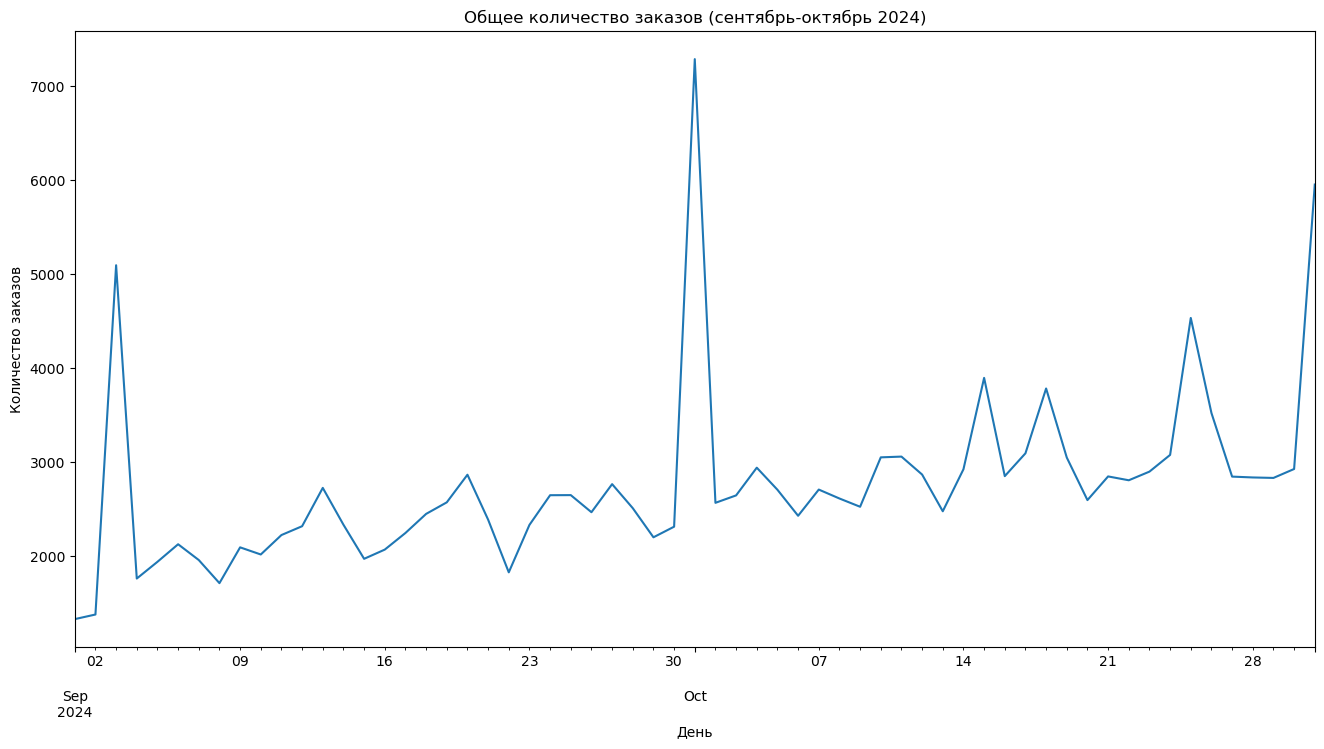

In [44]:
daily['orders'].plot(figsize=(16, 8))
plt.title('Общее количество заказов (сентябрь-октябрь 2024)')
plt.xlabel('День')
plt.ylabel('Количество заказов')

Text(0, 0.5, 'Уникальных пользователей')

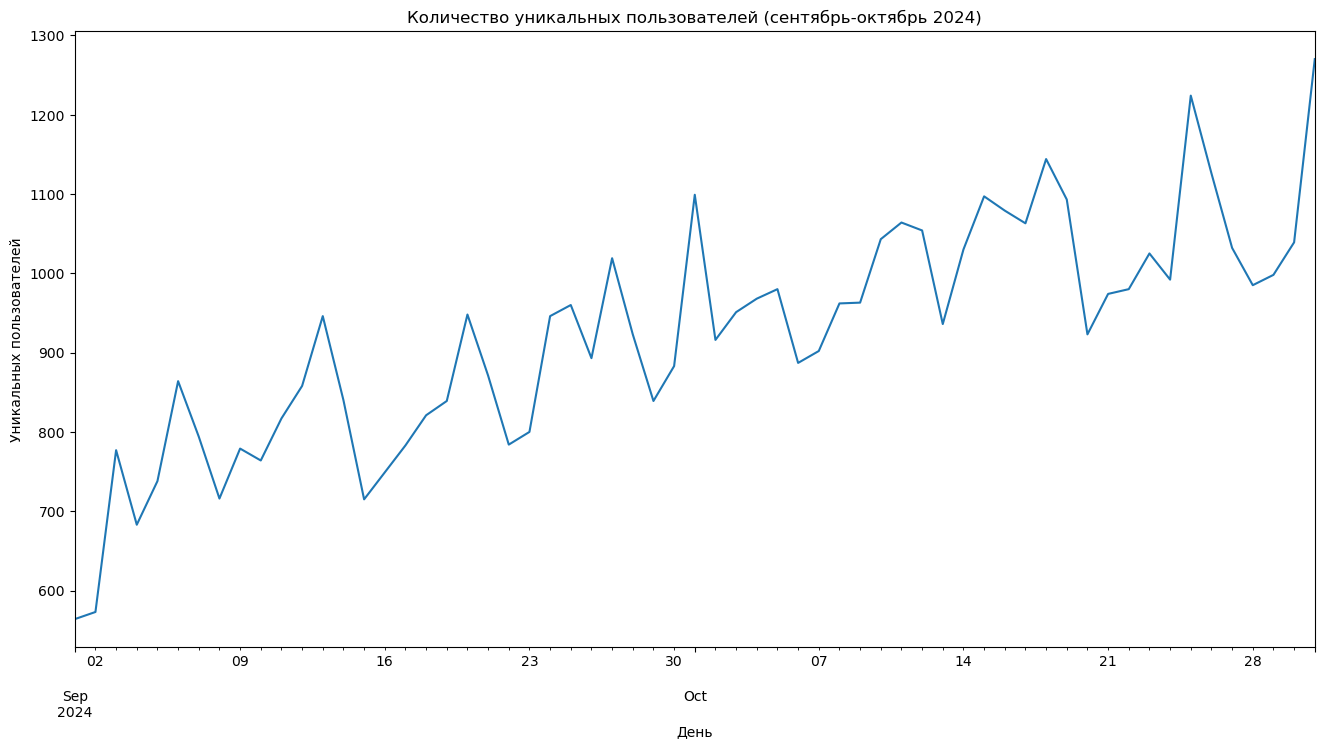

In [45]:
daily['dau'].plot(figsize=(16, 8))
plt.title('Количество уникальных пользователей (сентябрь-октябрь 2024)')
plt.xlabel('День')
plt.ylabel('Уникальных пользователей')

Text(0, 0.5, 'Цена билета (руб.)')

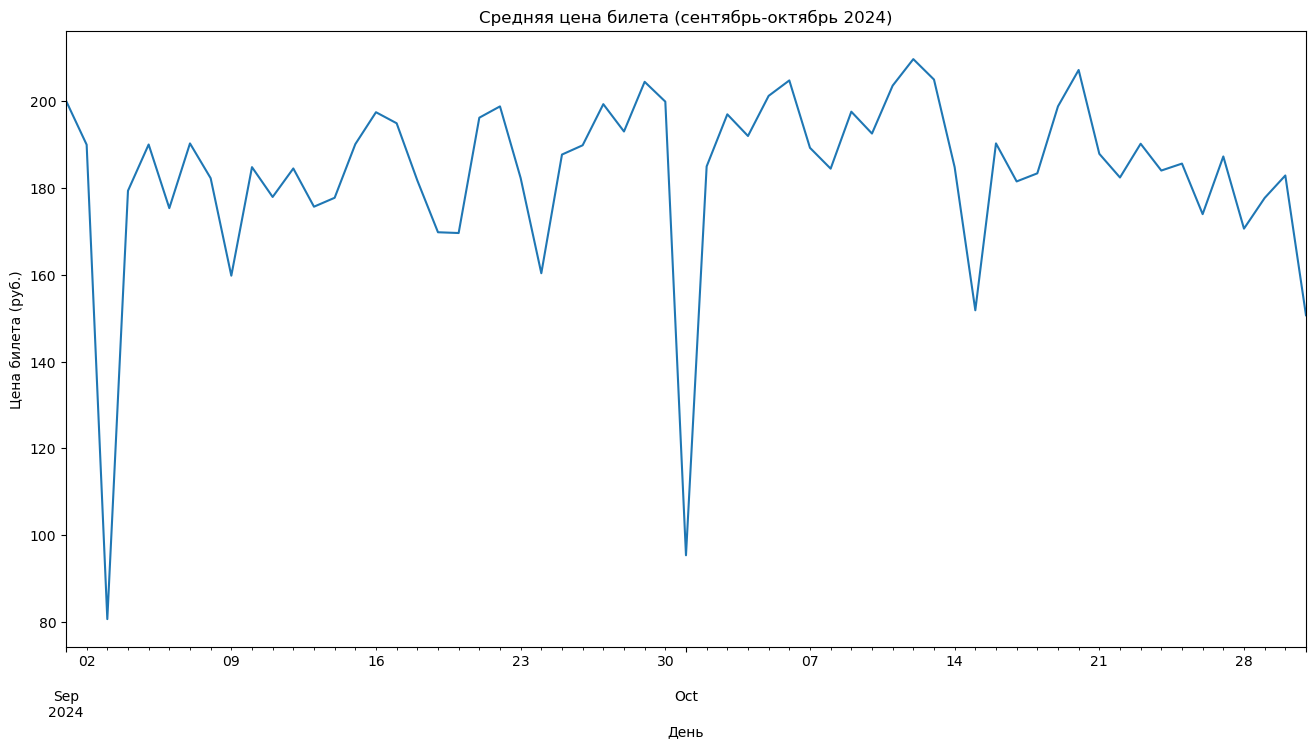

In [46]:
daily['avg_ticket_price'].plot(figsize=(16, 8))
plt.title('Средняя цена билета (сентябрь-октябрь 2024)')
plt.xlabel('День')
plt.ylabel('Цена билета (руб.)')

Text(0, 0.5, 'Заказов')

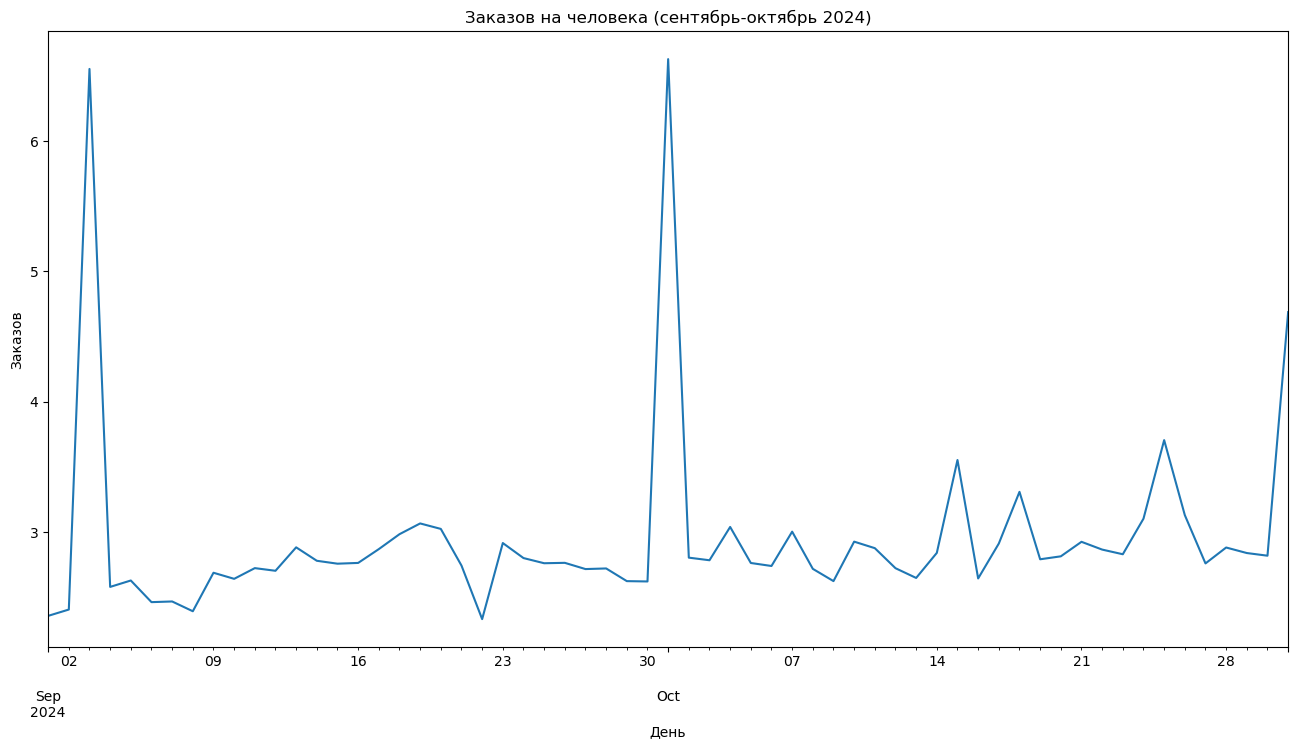

In [47]:
daily['orders_per_user'].plot(figsize=(16, 8))
plt.title('Заказов на человека (сентябрь-октябрь 2024)')
plt.xlabel('День')
plt.ylabel('Заказов')



- Общая тенденция по количеству заказов говорит о том, что пользователи приобретают большее количество билетов в начале месяца. Число заказов в сентябре резко вырастает в первую неделю сентября до 5 тыс., а затем колеблется от 2000 до 2500 тыс. заказов до 30 числа. В октябре заметна похожая тенденция: пик количества заказов заметен в начале и конце месяца (7 тыс. и 6 тыс. соответственно) и колебается от 3 до 4 тыс. заказов в течение остального месяца.
- Количество уникальных пользователей в день идет по восходящему тренду с колебаниями между 800 и 1000 чел. в сентябре до 900-1300 чел. в октябре.
- И в сентябре, и в октябре происходит пик заказов на одного пользователя, который затем спадает. В октябре колебание выражено более заметно, также есть пик в конце месяца.
- Средняя цена билета падает и в начале сентября, и в начале октября, то есть свопадает с временем наибольшего притока заказов.

- Изучим недельную цикличность.

In [48]:
# добавляем номер дня недели, название дня

daily = daily.copy()

daily['date'] = pd.to_datetime(daily.index)
daily['weekday'] = daily['date'].dt.dayofweek  # 0=понедельник, 6=воскресенье
daily['weekday_name'] = daily['date'].dt.day_name()

display(daily)

,orders,dau,avg_ticket_price,orders_per_user,date,weekday,weekday_name
created_dt_msk,,,,,,,
2024-09-01,1327,564,200.168708,2.352837,2024-09-01,6,Sunday
2024-09-02,1376,573,190.015637,2.401396,2024-09-02,0,Monday
2024-09-03,5094,777,80.650134,6.555985,2024-09-03,1,Tuesday
2024-09-04,1759,683,179.393891,2.575403,2024-09-04,2,Wednesday
2024-09-05,1937,738,190.058369,2.624661,2024-09-05,3,Thursday
...,...,...,...,...,...,...,...
2024-10-27,2844,1032,187.300193,2.755814,2024-10-27,6,Sunday
2024-10-28,2835,985,170.661577,2.878173,2024-10-28,0,Monday
2024-10-29,2830,998,177.732733,2.835671,2024-10-29,1,Tuesday


In [49]:
# собираем статистику по дням 

weekday_stats = (
    daily
    .groupby('weekday_name')[['orders', 'dau', 'orders_per_user', 'avg_ticket_price']]
    .mean()
    .reindex([
        'Monday', 'Tuesday', 'Wednesday', 'Thursday',
        'Friday', 'Saturday', 'Sunday'
    ])
)

display(weekday_stats)

,orders,dau,orders_per_user,avg_ticket_price
weekday_name,,,,
Monday,2387.111111,852.777778,2.779115,184.700598
Tuesday,3492.000000,934.000000,3.716721,156.967502
Wednesday,2537.111111,922.555556,2.748336,185.886105
Thursday,3011.222222,960.777778,3.060774,182.244642
Friday,3098.375000,1022.125000,2.998755,185.604197
Saturday,2665.000000,960.125000,2.761170,192.655601
Sunday,2152.111111,821.777778,2.598798,197.816890


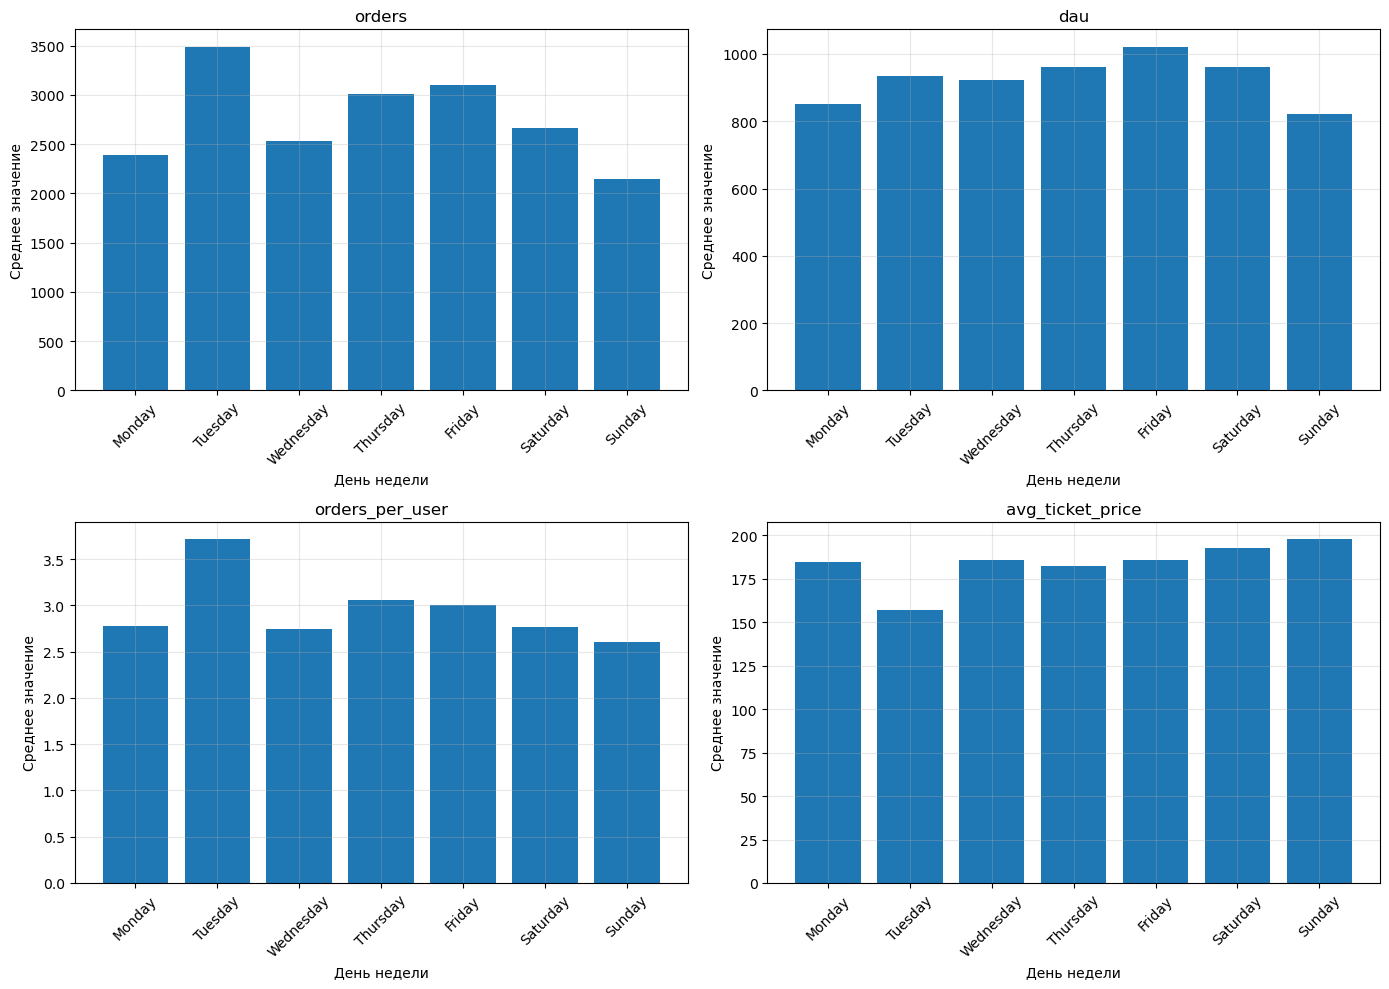

In [50]:
# добавим дополнительные графики, чтобы отследить кол-во заказов на одного человека


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['orders', 'dau', 'orders_per_user', 'avg_ticket_price']
for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    axes[row, col].bar(weekday_stats.index, weekday_stats[metric])
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel('Среднее значение')
    axes[row, col].set_xlabel('День недели')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
daily['is_weekend'] = daily['weekday'] >= 5

weekend_stats = (
    daily
    .groupby('is_weekend')[['orders', 'dau', 'orders_per_user', 'avg_ticket_price']]
    .mean()
)

weekend_stats.index = ['Будни', 'Выходные']
display(weekend_stats)

,orders,dau,orders_per_user,avg_ticket_price
Будни,2900.772727,936.545455,3.062149,178.932345
Выходные,2393.470588,886.882353,2.675208,195.388048


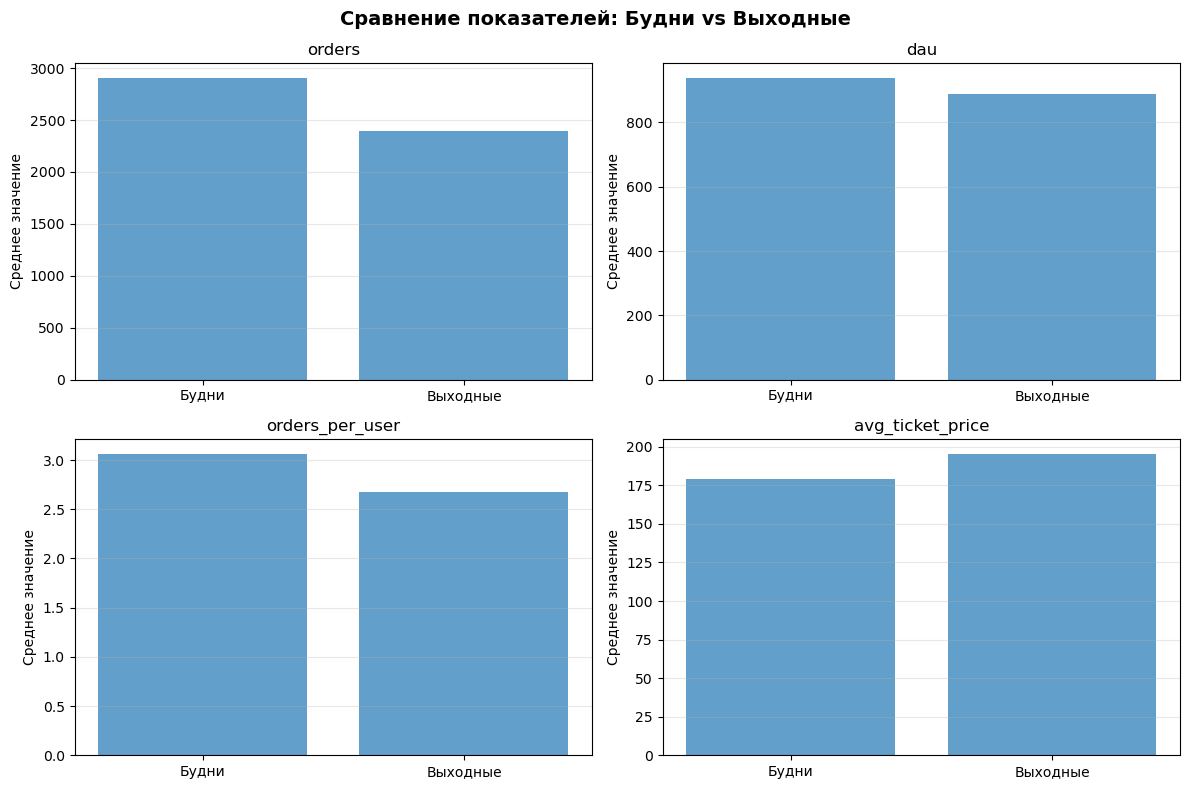

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = ['orders', 'dau', 'orders_per_user', 'avg_ticket_price']

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    axes[row, col].bar(weekend_stats.index, weekend_stats[metric], 
                    alpha=0.7)
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel('Среднее значение')
    axes[row, col].set_xlabel('')
    axes[row, col].tick_params(axis='x', rotation=0)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    

plt.suptitle('Сравнение показателей: Будни vs Выходные', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Предварительный вывод

- Пользователи активнее делают заказы по будням, пик активности замечен во вторник (в среднем 3500 заказов). По будням также выше и количество уникальных пользователей, и число заказов на одного пользователя.

Это может быть объяснено тем, что люди предпочитают планировать досуг на выходные заранее: чем ближе мероприятие, тем выше цена. Пользователи стараются выкупать билеты до повышенного спроса, чтобы сэкономить. Это подтверждается и высокой средней ценой билета на выходных в сравнении с показателями с понедельника по пятницу.

Показатель DAU во вторник не явялется максимальным показателем за всю неделю. Значит, что увеличение числа заказов не связано с притоком активных уникальных пользователей. 

Одновременно с этим именно во вторник показатель средней цены за билет самый низкий. Можно сделать вывод, что большое количество заказов во вторник связано именно с низкой ценой на билеты. 

### 3.3. Популярные события и партнёры
- Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов. 

In [53]:
# создаем аггрегированные данные
grouped_region = new_afisha.groupby('region_name').agg(
    orders=('order_id', 'count'),
    events=('event_id', 'nunique')
)

# добавляем столбцы с относительными значениями (в %)
grouped_region['orders_pct'] = (grouped_region['orders'] / grouped_region['orders'].sum()) * 100
grouped_region['events_pct'] = (grouped_region['events'] / grouped_region['events'].sum()) * 100

# сортируем по убыванию событий
grouped_region.sort_values('events', ascending=False).head(5)

,orders,events,orders_pct,events_pct
region_name,,,,
каменевский регион,89640,5933,31.212677,26.624484
североярская область,43608,3795,15.184320,17.030156
широковская область,16094,1225,5.603936,5.497218
светополянский округ,7486,1068,2.606628,4.792676
речиновская область,6265,701,2.181475,3.145755


- Для каждого билетного партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов.

In [54]:
# создаем агрегированные данные
grouped_service = new_afisha.groupby('service_name').agg(
    orders=('order_id', 'count'),
    events=('event_id', 'nunique'),
    sum_revenue=('revenue_rub', 'sum')
)

# добавляем относительные значения (в процентах)
grouped_service['orders_pct'] = (grouped_service['orders'] / grouped_service['orders'].sum()) * 100
grouped_service['events_pct'] = (grouped_service['events'] / grouped_service['events'].sum()) * 100
grouped_service['revenue_pct'] = (grouped_service['sum_revenue'] / grouped_service['sum_revenue'].sum()) * 100

# сортируем по убыванию количества мероприятий
grouped_service.sort_values('events', ascending=False).head(5)

,orders,events,sum_revenue,orders_pct,events_pct,revenue_pct
service_name,,,,,,
лови билет,40762,4859,1.667469e+07,14.193342,19.987659,11.183529
билеты без проблем,62500,4204,2.419579e+07,21.762520,17.293295,16.227849
билеты в руки,40181,3517,1.319219e+07,13.991037,14.467297,8.847856
облачко,26402,2335,1.858861e+07,9.193185,9.605101,12.467177
лучшие билеты,17706,1755,2.720730e+06,6.165235,7.219251,1.824764


### Предварительный вывод о популярных событиях и партнёрах
- Наибольшее разнообразие мероприятий (количество уникальных событий) предлагается в Каменевском районе (89665 заказов, то есть почти треть заказов от общего числа, и 5935 уникальных событий, то есть четверть уникальных мероприятий).
- Наиболее активный партнёр -- это "Лови билет", тут было проведено 4859 уникальных мероприятий (20% от общего числа). При этом больше всего выручки принес другой агрегатор -- "Билеты без проблем", где было оформлено больше всего заказов (62633), а относительное значение выручки от общего числа достигло 17%.
- Заметны также непропорциональную разницу между долями выручки и уникальных мероприятий у некоторых партнеров в топ-5. Например, на партнёра "Лучшие билеты" приходится 7% уникальных мероприятий, но только ~2% общей выручки. Одновременно с этим на партнёра "Облачко" пришлось 9% уникальных событий и 12% выручки. 

### Шаг 4. Статистический анализ данных


- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [55]:
# для начала нужно разделить пользователей по использованным устройствам
mobile = autumn_afisha[autumn_afisha['device_type_canonical'] == 'mobile']['user_id'] # id покупателей всех заказов с мобильных устройств 
desktop = autumn_afisha[autumn_afisha['device_type_canonical'] == 'desktop']['user_id'] # id покупателей всех заказов со стационарных устройств
mobile_id = mobile.unique()
desktop_id = desktop.unique()
print(f"Количество заказов с мобильных устройств: {len(mobile)}, количество заказов со стационарных устройств: {len(desktop)}")
print(f"Пользователей в группе мобильного приложения: {len(mobile_id)}, пользователей стационарных устройств: {len(desktop_id)}")

# затем проверяем, сколько пользователей находятся и в той, и в другой группе
intersection = list(set(mobile_id) & set(desktop_id))
print(f"Общих пользователей в обеих группах: {len(intersection)}")

print(f"Среднее количество заказов на одного пользователя мобильного приложения: {len(mobile)/len(mobile_id)}")
print(f"Среднее количество заказов на одного пользователя стационарного устройства: {len(desktop)/len(desktop_id)}")

Количество заказов с мобильных устройств: 134078, количество заказов со стационарных устройств: 34245
Пользователей в группе мобильного приложения: 14179, пользователей стационарных устройств: 4866
Общих пользователей в обеих группах: 3248
Среднее количество заказов на одного пользователя мобильного приложения: 9.456097044925594
Среднее количество заказов на одного пользователя стационарного устройства: 7.0376078914919855


In [56]:

# выделяем пользователей по устройствам
mobile_users = set(autumn_afisha[autumn_afisha['device_type_canonical'] == 'mobile']['user_id'].unique())
desktop_users = set(autumn_afisha[autumn_afisha['device_type_canonical'] == 'desktop']['user_id'].unique())

# Исключаем пользователей, которые есть в обеих группах
common_users = mobile_users & desktop_users
mobile_users_clean = mobile_users - common_users
desktop_users_clean = desktop_users - common_users

print(f"Пользователей mobile (без пересечений): {len(mobile_users_clean)}")
print(f"Пользователей desktop (без пересечений): {len(desktop_users_clean)}")
print(f"Исключено общих пользователей: {len(common_users)}")

# Фильтруем исходный датафрейм
mobile_clean = autumn_afisha[
    (autumn_afisha['device_type_canonical'] == 'mobile') & 
    (autumn_afisha['user_id'].isin(mobile_users_clean))
]
desktop_clean = autumn_afisha[
    (autumn_afisha['device_type_canonical'] == 'desktop') & 
    (autumn_afisha['user_id'].isin(desktop_users_clean))
]

# Считаем количество заказов на каждого пользователя
mobile_orders_per_user = mobile_clean.groupby('user_id').size()
desktop_orders_per_user = desktop_clean.groupby('user_id').size()

print(f"Среднее mobile (чистое): {mobile_orders_per_user.mean():.4f}")
print(f"Среднее desktop (чистое): {desktop_orders_per_user.mean():.4f}")

Пользователей mobile (без пересечений): 10931
Пользователей desktop (без пересечений): 1618
Исключено общих пользователей: 3248
Среднее mobile (чистое): 2.8574
Среднее desktop (чистое): 1.9710


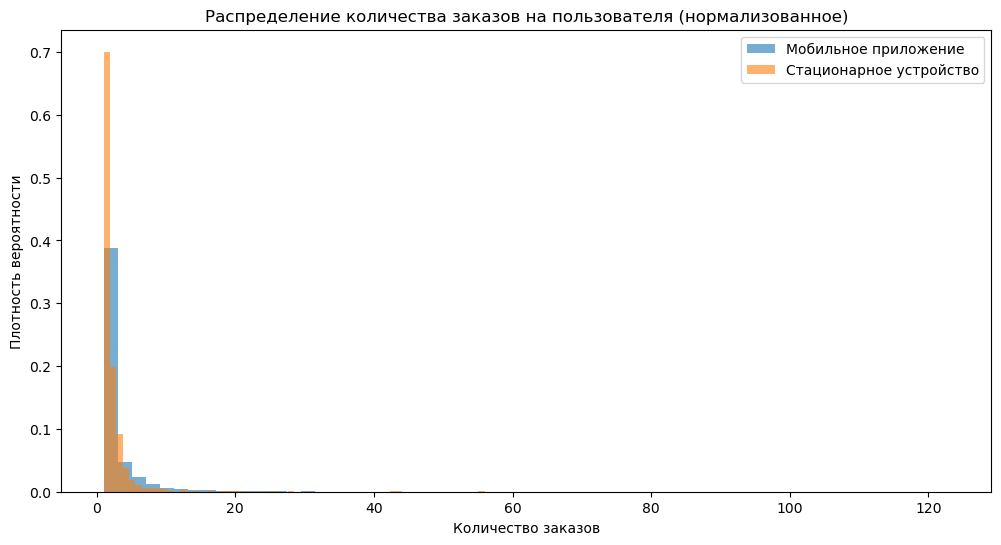

In [58]:
mobile_counts = mobile_clean.groupby('user_id')['order_id'].count()
desktop_counts = desktop_clean.groupby('user_id')['order_id'].count()

# Строим нормализованные гистограммы
plt.figure(figsize=(12, 6))
plt.hist(mobile_counts, bins=60, density=True, alpha=0.6, label='Мобильное приложение')
plt.hist(desktop_counts, bins=60, density=True, alpha=0.6, label='Стационарное устройство')
plt.title('Распределение количества заказов на пользователя (нормализованное)')
plt.xlabel('Количество заказов')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.show()

### Формулировка гипотез

Нулевая гипотеза (H0): Среднее количество заказов на пользователя в мобильном приложении меньше или равно среднему количеству заказов на пользователя стационарных устройств.

Альтернативная гипотеза (H1): Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [60]:
t_stat, p = stats.ttest_ind(mobile_orders_per_user, desktop_orders_per_user, 
                            equal_var=False,  
                            alternative='greater') 


print(f'p-value = {p}')

if p < 0.05:
    print("Отвергаем H0: среднее количество заказов на пользователя мобильных приложений значимо выше, чем у пользователей стационарных устройств")
else:
    print("Нет оснований отвергнуть H0")

p-value = 5.585599899631944e-25
Отвергаем H0: среднее количество заказов на пользователя мобильных приложений значимо выше, чем у пользователей стационарных устройств




Тест Уэлча подтвердил альтернативную гипотезу. Среднее количество заказов на пользователя мобильного приложения выше, чем у пользователя стационарного устройства.

### Проверка среднего времени между заказами пользователей приложений и пользователей стационарных устройств
- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [61]:
# так как в days_since_prev есть пропуски, для корректного выполнения теста их нужно убрать 

mobile = mobile_clean['days_since_prev'].dropna()
desktop = desktop_clean['days_since_prev'].dropna()

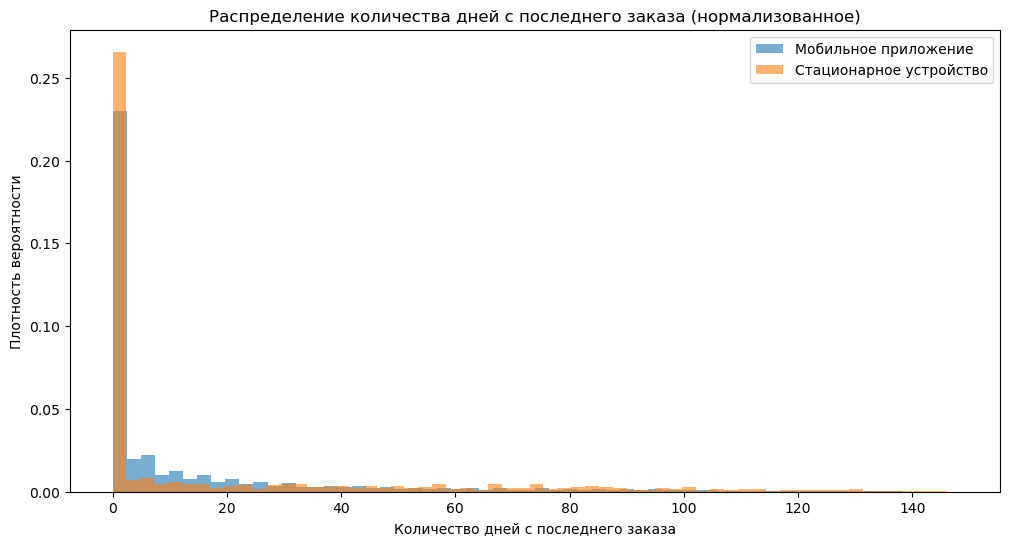

In [63]:
plt.figure(figsize=(12, 6))
plt.hist(mobile, bins=60, density=True, alpha=0.6, label='Мобильное приложение')
plt.hist(desktop, bins=60, density=True, alpha=0.6, label='Стационарное устройство')
plt.title('Распределение количества дней с последнего заказа (нормализованное)')
plt.xlabel('Количество дней с последнего заказа')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.show()

#### Формулировка гипотез

**Нулевая гипотеза (H0**): Среднее время между заказами пользователей мобильных приложений меньше или равно среднему времени между заказами у пользователей стационарных устройств.

**Альтернативная гипотеза (H1)**: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [65]:
t_stat, p = stats.ttest_ind(mobile, desktop, 
                            equal_var=False, 
                            alternative='greater') 

print(f'p-value = {p}')

if p < 0.05:
    print("Отвергаем H₀: у пользователей мобильных приложений среднее время между заказами выше")
else:
    print("Нет оснований отвергнуть H0")

p-value = 0.9999999977243023
Нет оснований отвергнуть H0


### Предварительный вывод второго статистического теста

Статистический тест показал, что имеющихся данных недостаточно для подтверждения гипотезы о том, что среднее время между заказами у пользователей мобильных приложений выше.

## Заключительный вывод и рекомендации


### Информация о данных

Для работы были предоставлен датасет Яндекс Афиши, который содержал информацию о заказах билетов на различные мероприятия за период с 1 июня по 31 октября 2024 года. В данных были представлены две валюты: рубли и тенге. 

Для корретного проведения статистического и исследовательского анализа были удалены дубликаты, исключены выбросы и экстремально высокие значения. Тенге были переведены в рубли согласно информации о курсе за 2024 год.

### Сезонные тенденции
- Общее количество заказов с июня по октябрь растёт. Доля заказов выше всего в октябре (35% от общего числа). Наиболее востребованные мероприятия -- это театральные выступления и концерты. Осенью количество заказов на мероприятия с возрастным рейтином 0+ растёт, а с рейтингом 18+ -- падает. Начинается продажа билетов на ёлки. 
- Динамика средней выручки с заказа билета меняется и падает для всех категорий осенью, исключая спортивные мероприятия и стендапы. 
- Распределение заказов в зависимости от типа устройства (стационарного устройства или мобильных приложений) остаётся практически одинаковой и летом, и осенью. Преобладают заказы, сделанные с мобильных приложений.
- При сравнении между сентябрем и октябрем заметно, что в среднем больше всего заказов приходится на второй осенний месяц. К его концу заметны восходящие тенденции показателей DAU, общего числа заказов и заказов на одного пользователя. При этом средняя цена билета падает. 

Это значит, что осенью люди покупают билеты чаще, а цены на них падают.

### Пользовательская активность
- Больше всего заказов, уникальных пользователей и билетов на один заказ приходится на будни, на вторник. 
- DAU выше всего в пятницу. Это может сигнализировать о том, что люди планируют досуг на выходные.
- При этом средняя цена билета выше на выходных.

### Популярные события и партнёры
- Больше всего заказов и уникальных событий приходится на Каменевский регион (31% и 27% от общего числа соответственно).
- В партнёрах сервиса выделяется два: "Лови билет" и "Билеты без проблем". Больше всего уникальных событий пришлось на первый сервис (20%), тогда как на второй приходится наибольшая доля заказов и выручки (22% и 16%).

### Среднее количество заказов и средняя разница между заказами на одного пользователя в зависимости от устройства
- Статистический тест показал, что пользователи мобильных приложений оформляют больше заказов, чем пользователи стационарных устройств. 
- При этом гипотеза о том, что пользователи мобильных приложений в среднем оформляют заказы реже, чем пользователи стационарных устройств, **не подтвердилась.**

## Общие рекомендации
1. Необходимо стимулировать покупки билетов в субботу и воскресенье, так как пик пользовательской активности приходится на пятницу, а средняя цена билета на выходных выше, чем по будням. Это выгоднее для сервиса. Одновременно с этим продолжать стимулировать продажи во вторник.
2. Обратить внимание на другие регионы помимо Каменевского района и изучить, почему в других регионах показатели ниже.
2. Стимулировать частоту заказов у пользователей мобильных приложений, например пушами или акциями на вторую покупку билета в ограниченный срок после предыдущей покупки.
3. Смягчить падение средней выручки осенью: создавать искусственные дефициты на билеты. Обратить внимание на восходящие тренды октября и начать планирование предновогодней кампании.